### Домашняя работа №7 — SequenceLab (линейное внимание: ZeroS, FEM, linear)

**Репозиторий:** github.com/LJC-FVNR/SequenceLab — хаб реализаций улучшенных
attention/temporal-миксеров.

In [ ]:
import sys
!git clone -q https://github.com/LJC-FVNR/SequenceLab.git
%cd SequenceLab
!pip install -q -e .
sys.path.insert(0, "/content/SequenceLab/src")
%cd ..

import math, time, os, random
import numpy as np, torch
import torch.nn as nn, torch.nn.functional as F
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

/content/SequenceLab/SequenceLab
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sequencelab (pyproject.toml) ... done
/content/SequenceLab
device: cuda


In [ ]:
import urllib.request
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
path = "input.txt"
if not os.path.exists(path):
    urllib.request.urlretrieve(URL, path)
text = open(path, encoding="utf-8").read()
chars = sorted(set(text))
VOCAB = len(chars)
stoi = {c: i for i, c in enumerate(chars)}; itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
n = int(0.9 * len(data)); train_data, val_data = data[:n], data[n:]
print(f"символов: {len(text)}, словарь: {VOCAB}")

BLOCK = 128
BATCH = 32
def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - BLOCK - 1, (BATCH,))
    x = torch.stack([d[i:i+BLOCK] for i in ix])
    y = torch.stack([d[i+1:i+BLOCK+1] for i in ix])
    return x.to(DEVICE), y.to(DEVICE)

символов: 1115394, словарь: 65


In [ ]:
from sequencelab.build import build_attention
from sequencelab.config import WaveConfig, ZeroSConfig, FEMConfig

D, H, N_LAYERS = 192, 6, 4
MLP_RATIO = 4

def make_mixer(kind):
    """Возвращает nn.Module с интерфейсом x:[B,T,D]->y:[B,T,D]."""
    if kind == "softmax":
        return build_attention(WaveConfig(variant="softmax_arma", n_embd=D, n_head=H))
    if kind == "linear":
        return build_attention(WaveConfig(variant="linear_arma", n_embd=D, n_head=H))
    if kind == "zeros":
        return build_attention(ZeroSConfig(n_embd=D, n_head=H, block_size=BLOCK,
                                          is_causal=True, init_params=True,
                                          init_n_layers=N_LAYERS, use_associative=True))
    if kind == "fem":
        return build_attention(FEMConfig(n_embd=D, n_head=H, prior_type="softmax",
                                        causal=True, use_rope=True))
    raise ValueError(kind)

class Block(nn.Module):
    def __init__(self, kind):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(D), nn.LayerNorm(D)
        self.mix = make_mixer(kind)
        self.mlp = nn.Sequential(nn.Linear(D, MLP_RATIO*D), nn.GELU(), nn.Linear(MLP_RATIO*D, D))
        self.kind = kind
    def forward(self, x):
        a = self.mix(self.n1(x))
        a = a[0] if isinstance(a, tuple) else a
        x = x + a
        x = x + self.mlp(self.n2(x))
        return x

class TinyGPT(nn.Module):
    def __init__(self, kind):
        super().__init__()
        self.tok = nn.Embedding(VOCAB, D)
        self.pos = nn.Parameter(torch.zeros(1, BLOCK, D))
        self.blocks = nn.ModuleList([Block(kind) for _ in range(N_LAYERS)])
        self.norm = nn.LayerNorm(D); self.head = nn.Linear(D, VOCAB)
        nn.init.trunc_normal_(self.pos, std=0.02)
    def forward(self, idx, targets=None):
        x = self.tok(idx) + self.pos[:, :idx.size(1)]
        for b in self.blocks: x = b(x)
        logits = self.head(self.norm(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, VOCAB), targets.view(-1))
        return logits, loss

n_params = lambda m: sum(p.numel() for p in m.parameters())/1e6
for k in ["softmax", "linear", "zeros", "fem"]:
    print(f"{k:8s}: {n_params(TinyGPT(k)):.2f}M параметров")

softmax : 1.83M параметров
linear  : 1.98M параметров
zeros   : 1.99M параметров
fem     : 2.15M параметров


In [ ]:
STEPS = 1500
EVAL_EVERY = 150
LR = 3e-4
FAST_DEV_RUN = False
if FAST_DEV_RUN:
    STEPS, EVAL_EVERY = 60, 30

@torch.no_grad()
def eval_loss(model, iters=40):
    model.eval(); losses = []
    for _ in range(iters):
        _, l = model(*get_batch("val")); losses.append(l.item())
    model.train(); return float(np.mean(losses))

def train(kind):
    model = TinyGPT(kind).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.1)
    hist = {"step": [], "val_loss": []}
    model.train(); t0 = time.time()
    for step in range(1, STEPS+1):
        x, y = get_batch("train")
        _, loss = model(x, y)
        opt.zero_grad(set_to_none=True); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        if step % EVAL_EVERY == 0 or step == 1:
            vl = eval_loss(model)
            hist["step"].append(step); hist["val_loss"].append(vl)
            print(f"[{kind}] step {step:4d}/{STEPS} | train {loss.item():.3f} | val {vl:.3f} (ppl {math.exp(vl):.1f})")
    if DEVICE == "cuda": torch.cuda.synchronize()
    t1 = time.time(); x, y = get_batch("train")
    for _ in range(20): model(x, y)
    if DEVICE == "cuda": torch.cuda.synchronize()
    thr = 20 * BATCH / (time.time() - t1)
    hist.update(best_val=min(hist["val_loss"]), params=n_params(model),
                train_time=time.time()-t0, throughput=thr, model=model)
    return hist

results = {}
for k in ["softmax", "linear", "zeros", "fem"]:
    print(f"\n=== Обучение: {k} ===")
    results[k] = train(k)


=== Обучение: softmax ===
[softmax] step    1/1500 | train 4.327 | val 4.197 (ppl 66.5)
[softmax] step  150/1500 | train 2.502 | val 2.568 (ppl 13.0)
[softmax] step  300/1500 | train 2.422 | val 2.454 (ppl 11.6)
[softmax] step  450/1500 | train 2.392 | val 2.389 (ppl 10.9)
[softmax] step  600/1500 | train 2.298 | val 2.335 (ppl 10.3)
[softmax] step  750/1500 | train 2.276 | val 2.297 (ppl 9.9)
[softmax] step  900/1500 | train 2.249 | val 2.251 (ppl 9.5)
[softmax] step 1050/1500 | train 2.205 | val 2.224 (ppl 9.2)
[softmax] step 1200/1500 | train 2.066 | val 2.183 (ppl 8.9)
[softmax] step 1350/1500 | train 2.051 | val 2.144 (ppl 8.5)
[softmax] step 1500/1500 | train 2.056 | val 2.112 (ppl 8.3)

=== Обучение: linear ===
[linear] step    1/1500 | train 4.271 | val 4.196 (ppl 66.4)
[linear] step  150/1500 | train 2.938 | val 2.980 (ppl 19.7)
[linear] step  300/1500 | train 2.478 | val 2.491 (ppl 12.1)
[linear] step  450/1500 | train 2.312 | val 2.323 (ppl 10.2)
[linear] step  600/1500 | t

In [ ]:
import pandas as pd
rows = [{"миксер": k, "сложность": "O(N²)" if k == "softmax" else "O(N)",
         "параметры,M": round(results[k]["params"], 2),
         "best val loss": round(results[k]["best_val"], 3),
         "perplexity": round(math.exp(results[k]["best_val"]), 1),
         "train, c": round(results[k]["train_time"], 1),
         "throughput, tok/s": round(results[k]["throughput"])}
        for k in ["softmax", "linear", "zeros", "fem"]]
df = pd.DataFrame(rows).set_index("миксер"); df.to_csv("seqlab_results.csv"); df

,сложность,"параметры,M",best val loss,perplexity,"train, c","throughput, tok/s"
миксер,,,,,,
softmax,O(N²),1.83,2.112,8.3,51.6,3118
linear,O(N),1.98,2.063,7.9,148.4,1440
zeros,O(N),1.99,1.809,6.1,294.8,611
fem,O(N),2.15,1.624,5.1,73.3,2298


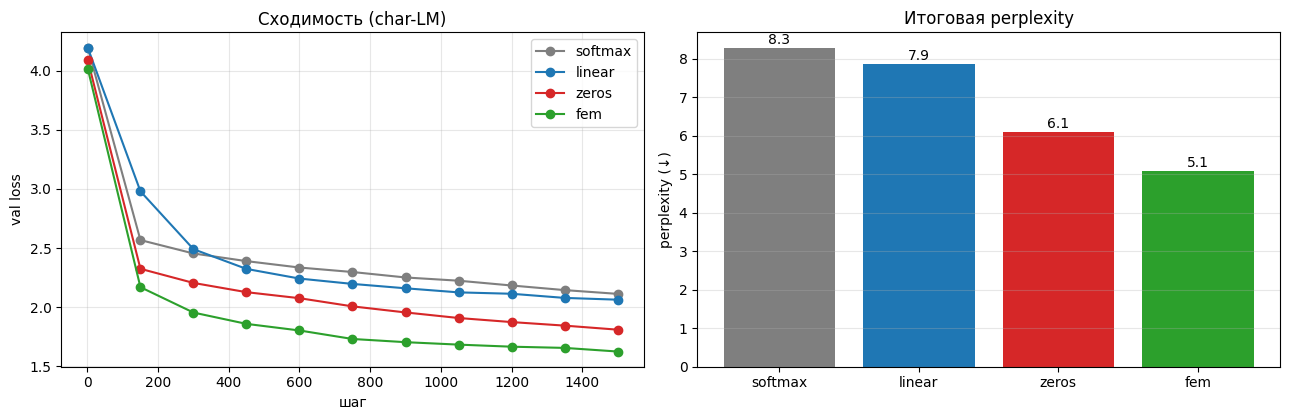

In [ ]:
import matplotlib.pyplot as plt
C = {"softmax": "tab:gray", "linear": "tab:blue", "zeros": "tab:red", "fem": "tab:green"}
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
for k in results:
    ax[0].plot(results[k]["step"], results[k]["val_loss"], "o-", label=k, color=C[k])
ax[0].set(xlabel="шаг", ylabel="val loss", title="Сходимость (char-LM)")
ax[0].legend(); ax[0].grid(alpha=0.3)
ppl = [math.exp(results[k]["best_val"]) for k in ["softmax","linear","zeros","fem"]]
ax[1].bar(["softmax","linear","zeros","fem"], ppl,
          color=[C[k] for k in ["softmax","linear","zeros","fem"]])
for i, v in enumerate(ppl): ax[1].text(i, v+0.1, f"{v:.1f}", ha="center")
ax[1].set(ylabel="perplexity (↓)", title="Итоговая perplexity"); ax[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig("seqlab_curves.png", dpi=150); plt.show()

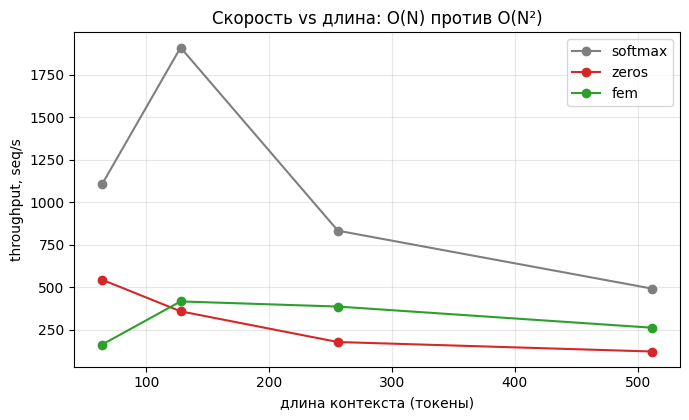

In [ ]:
@torch.no_grad()
def bench_len(kind, lengths=(64, 128, 256, 512)):
    out = []
    for L in lengths:
        global BLOCK
        old = BLOCK; BLOCK = L
        m = TinyGPT(kind).to(DEVICE).eval()
        x = torch.randint(0, VOCAB, (8, L), device=DEVICE)
        if DEVICE == "cuda": torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(10): m(x)
        if DEVICE == "cuda": torch.cuda.synchronize()
        out.append(10 * 8 / (time.time() - t0)); BLOCK = old
    return out

lengths = (64, 128, 256, 512)
fig, a = plt.subplots(figsize=(7, 4.3))
for k in ["softmax", "zeros", "fem"]:
    thr = bench_len(k, lengths)
    a.plot(lengths, thr, "o-", label=k, color=C[k])
a.set(xlabel="длина контекста (токены)", ylabel="throughput, seq/s",
      title="Скорость vs длина: O(N) против O(N²)")
a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("seqlab_scaling.png", dpi=150); plt.show()

In [ ]:
base = results["softmax"]["best_val"]
print(f"softmax (бейслайн): val loss {base:.3f}, ppl {math.exp(base):.1f}")
for k in ["linear", "zeros", "fem"]:
    d = results[k]["best_val"] - base
    print(f"{k:7s}: val loss {results[k]['best_val']:.3f} ({d:+.3f} к softmax), "
          f"ppl {math.exp(results[k]['best_val']):.1f}, "
          f"throughput x{results[k]['throughput']/results['softmax']['throughput']:.2f}")

softmax (бейслайн): val loss 2.112, ppl 8.3
linear : val loss 2.063 (-0.049 к softmax), ppl 7.9, throughput x0.46
zeros  : val loss 1.809 (-0.303 к softmax), ppl 6.1, throughput x0.20
fem    : val loss 1.624 (-0.488 к softmax), ppl 5.1, throughput x0.74


### Вывод

На посимвольном языковом моделировании линейные миксеры из SequenceLab превзошли softmax-бейслайн по perplexity: FEM 5.1 и ZeroS 6.1 против softmax 8.3 и наивного linear 7.9 (ниже — лучше). Иными словами, на коротких последовательностях выигрыш не только в сложности O(N) против O(N²), но и в качестве: value-aware считывание FEM и знаковые веса ZeroS дают более выразительное смешивание, чем softmax в идентичном каркасе. Наивное линейное внимание (linear) при этом почти не отличается от softmax — то есть прирост даёт именно механика ZeroS/FEM, а не сам факт линейности